<a href="https://colab.research.google.com/github/JavierTovar19/IA_minibots_T6-machine_learning/blob/main/P3_ARBOL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Matriz de confusión:
[[113   4]
 [  5  28]]

Reporte de clasificación:
              precision    recall  f1-score   support

     Clase A       0.96      0.97      0.96       117
     Clase B       0.88      0.85      0.86        33

    accuracy                           0.94       150
   macro avg       0.92      0.91      0.91       150
weighted avg       0.94      0.94      0.94       150



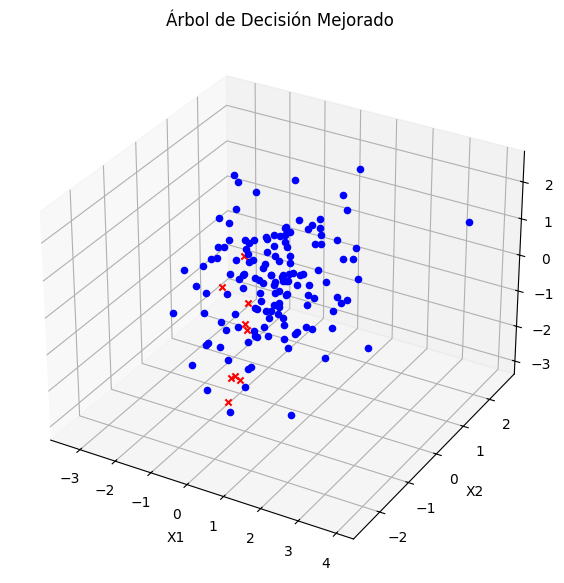

In [6]:
# =========================
# 1. LIBRERÍAS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

from mpl_toolkits.mplot3d import Axes3D

# =========================
# 2. CARGA DE DATOS (MEJORADOS)
# =========================
np.random.seed(42)

n = 500  # más datos

x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(2, 1, n)
x3 = np.random.normal(-1, 1, n)

data = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "x3": x3
})

# Regla REAL (ahora sí hay patrón)
data["label"] = pd.Series(x1 + x2 > 1).map({
    True: "Clase A",
    False: "Clase B"
})



# =========================
# 3. VARIABLES
# =========================
features = ["x1", "x2", "x3"]
X = data[features]
y = data["label"]

# =========================
# 4. NORMALIZACIÓN
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 5. TRAIN / TEST
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# =========================
# 6. MODELO (MEJORADO)
# =========================
model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# =========================
# 7. PREDICCIÓN
# =========================
y_pred = model.predict(X_test)

# =========================
# 8. MATRIZ DE CONFUSIÓN
# =========================
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# =========================
# 9. VISUALIZACIÓN 3D
# =========================
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

X_test_np = np.array(X_test)

colors = []
markers = []

for i in range(len(y_test)):
    if y_test.iloc[i] == y_pred[i]:
        colors.append('blue')   # correcto
        markers.append('o')
    else:
        colors.append('red')    # incorrecto
        markers.append('x')

for i in range(len(X_test_np)):
    ax.scatter(
        X_test_np[i,0],
        X_test_np[i,1],
        X_test_np[i,2],
        c=colors[i],
        marker=markers[i]
    )

ax.set_title("Árbol de Decisión Mejorado")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")

plt.show()